# Flight Delay Prediction
This notebook implements the steps to cleanse the data, build a model, and export results as described in the `1-create-model-data.md` file.

In [130]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

## Load the dataset
Load the flight data from the CSV file.

In [131]:
# Load the dataset
file_path = 'data/flights.csv'
data = pd.read_csv(file_path)
data.head()

,Year,Month,DayofMonth,DayOfWeek,Carrier,OriginAirportID,OriginAirportName,OriginCity,OriginState,DestAirportID,DestAirportName,DestCity,DestState,CRSDepTime,DepDelay,DepDel15,CRSArrTime,ArrDelay,ArrDel15,Cancelled
0,2013,9,16,1,DL,15304,Tampa International,Tampa,FL,12478,John F. Kennedy International,New York,NY,1539,4,0.0,1824,13,0,0
1,2013,9,23,1,WN,14122,Pittsburgh International,Pittsburgh,PA,13232,Chicago Midway International,Chicago,IL,710,3,0.0,740,22,1,0
2,2013,9,7,6,AS,14747,Seattle/Tacoma International,Seattle,WA,11278,Ronald Reagan Washington National,Washington,DC,810,-3,0.0,1614,-7,0,0
3,2013,7,22,1,OO,13930,Chicago O'Hare International,Chicago,IL,11042,Cleveland-Hopkins International,Cleveland,OH,804,35,1.0,1027,33,1,0
4,2013,5,16,4,DL,13931,Norfolk International,Norfolk,VA,10397,Hartsfield-Jackson Atlanta International,Atlanta,GA,545,-1,0.0,728,-9,0,0


## Data Cleansing
Identify and replace null values with appropriate values (e.g., zero).

In [132]:
# Replace null values with zero
data.fillna(0, inplace=True)
data.isnull().sum()

Year                 0
Month                0
DayofMonth           0
DayOfWeek            0
Carrier              0
OriginAirportID      0
OriginAirportName    0
OriginCity           0
OriginState          0
DestAirportID        0
DestAirportName      0
DestCity             0
DestState            0
CRSDepTime           0
DepDelay             0
DepDel15             0
CRSArrTime           0
ArrDelay             0
ArrDel15             0
Cancelled            0
dtype: int64

## Feature Engineering
Prepare the data for model training by selecting relevant features and target variables.

## Update Input Features
Modify the input features to match the backend logic.

In [ ]:
# Update features to match backend logic
features = ['DayOfWeek', 'OriginAirportID']
target = 'DepDel15'
X = data[features]
y = data[target]

## Train-Test Split
Split the data into training and testing sets.

In [134]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Training
Train a Random Forest Classifier to predict flight delays.

In [135]:
# Train the model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Model Evaluation
Evaluate the model's performance on the test set.

In [136]:
# Evaluate the model
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      1.00      0.88     42766
           1       0.00      0.00      0.00     11622

    accuracy                           0.79     54388
   macro avg       0.39      0.50      0.44     54388
weighted avg       0.62      0.79      0.69     54388



/Users/edvins.lazarevics/Documents/projects/flight-delay-hackaton/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/edvins.lazarevics/Documents/projects/flight-delay-hackaton/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/edvins.lazarevics/Documents/projects/flight-delay-hackaton/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples

## Export Results
Export the list of all airports and their associated IDs to a new CSV file.

In [137]:
# Export airport data
airports = data[['OriginAirportID', 'OriginAirportName']].drop_duplicates()
airports.to_csv('data/airports.csv', index=False)

## Confusion Matrix
Visualize the confusion matrix to better understand the model's predictions.

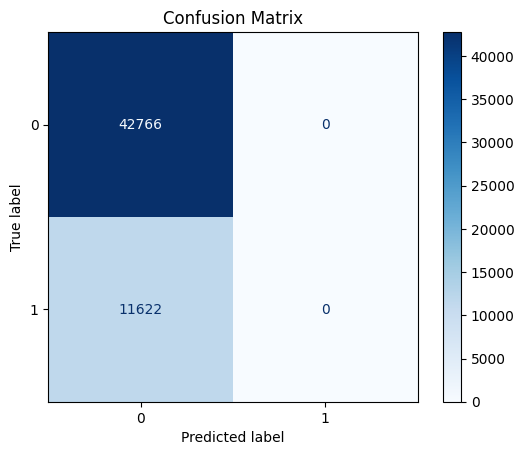

In [138]:
# Plot confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

## Feature Importance
Analyze the importance of each feature in the Random Forest model.

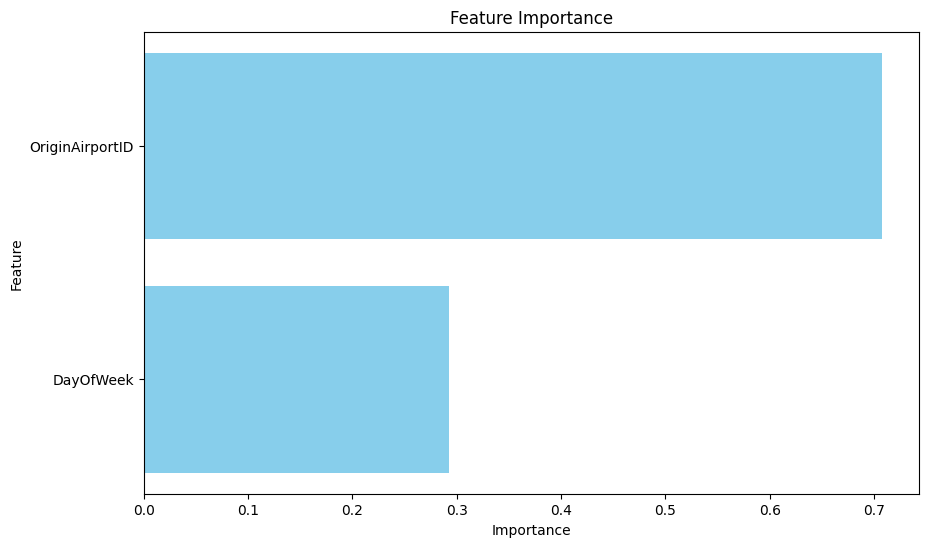

In [139]:
# Plot feature importance
importances = model.feature_importances_
feature_names = features

plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances, color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.show()

## ROC Curve
Plot the ROC curve to evaluate the model's ability to distinguish between classes.

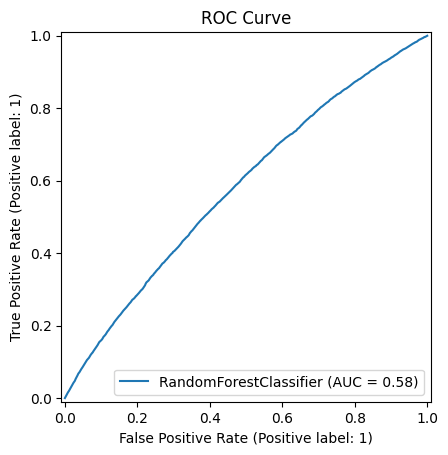

In [140]:
# Plot ROC curve
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title('ROC Curve')
plt.show()

## Export Balanced Model for Backend
Export the retrained balanced model to a file for use in the backend.

In [141]:
# Export the balanced trained model
import joblib

balanced_model_file = 'model/flight_delay_model_balanced.pkl'
joblib.dump(model_balanced, balanced_model_file)
print(f'Balanced model exported to {balanced_model_file}')

Balanced model exported to model/flight_delay_model_balanced.pkl


## Check Class Imbalance
Analyze the distribution of the target variable (`DepDel15`) to identify any class imbalance.

ArrDel15
0    213220
1     58720
Name: count, dtype: int64


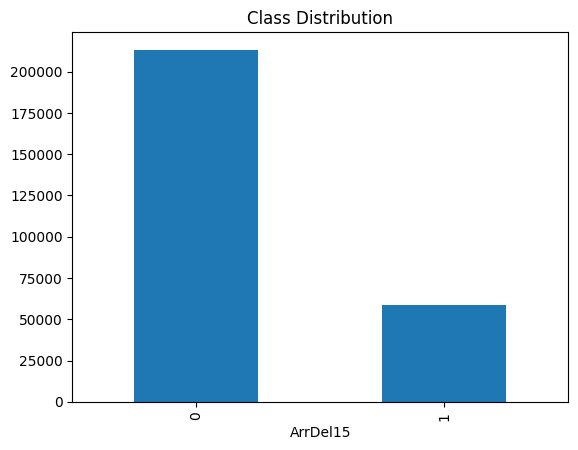

In [142]:
# Check class distribution
class_counts = y.value_counts()
print(class_counts)
class_counts.plot(kind='bar', title='Class Distribution');

## Balance the Dataset
Apply oversampling to balance the classes in the target variable (`DepDel15`).

In [143]:
# Balance the dataset using oversampling
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_balanced, y_balanced = ros.fit_resample(X, y)
print(f'Balanced class distribution: {y_balanced.value_counts()}')

Balanced class distribution: ArrDel15
0    213220
1    213220
Name: count, dtype: int64


/Users/edvins.lazarevics/Documents/projects/flight-delay-hackaton/.venv/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/edvins.lazarevics/Documents/projects/flight-delay-hackaton/.venv/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


## Retrain the Model
Retrain the Random Forest Classifier using the balanced dataset.

In [144]:
# Split the balanced data
X_train_balanced, X_test_balanced, y_train_balanced, y_test_balanced = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42
)

# Retrain the model
model_balanced = RandomForestClassifier(random_state=42)
model_balanced.fit(X_train_balanced, y_train_balanced)

RandomForestClassifier(random_state=42)

## Evaluate the Balanced Model
Evaluate the performance of the retrained model using the balanced test set.

              precision    recall  f1-score   support

           0       0.56      0.55      0.55     42630
           1       0.55      0.56      0.56     42658

    accuracy                           0.56     85288
   macro avg       0.56      0.56      0.56     85288
weighted avg       0.56      0.56      0.56     85288



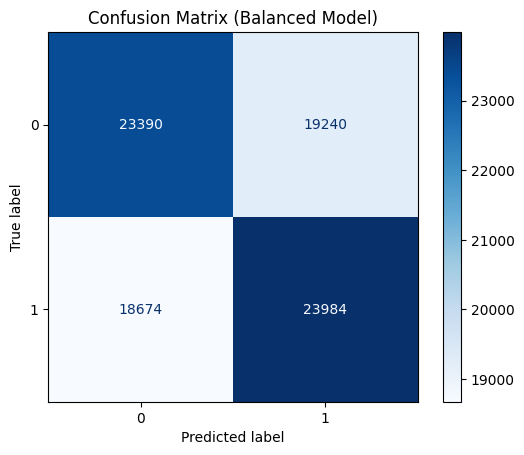

In [145]:
# Evaluate the balanced model
y_pred_balanced = model_balanced.predict(X_test_balanced)
print(classification_report(y_test_balanced, y_pred_balanced))

# Plot confusion matrix for balanced model
ConfusionMatrixDisplay.from_estimator(model_balanced, X_test_balanced, y_test_balanced, cmap='Blues')
plt.title('Confusion Matrix (Balanced Model)')
plt.show()

## Predict Function
Create a function to predict delay chance and confidence for backend integration.

In [146]:
# Define predict function
def predict_delay(day_of_week, airport_id):
    input_data = pd.DataFrame([[day_of_week, airport_id]], columns=['DayOfWeek', 'OriginAirportID'])
    delay_chance = model.predict_proba(input_data)[0][1]
    confidence = model.predict_proba(input_data).max() * 100
    return {
        'delay_chance': delay_chance,
        'confidence': confidence
    }

# Example usage
example_prediction = predict_delay(1, 15304)
print(example_prediction)

{'delay_chance': np.float64(0.17042807827079565), 'confidence': np.float64(82.95719217292043)}
